<a href="https://colab.research.google.com/github/martincastanonicolas-source/AI/blob/master/04-seaborn/seaborn_techstore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seaborn: TechStore

**Análisis comercial de ventas tecnológicas**

> Generado desde [Kobalto Cursos](https://kobalto.com) - 2/3/2026


## Setup

Importación de librerías necesarias:


In [22]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
matplotlib.use('inline')

## Carga de Datos

Ejecuta esta celda para cargar el dataset:


In [23]:
np.random.seed(2024)
n = 2400

meses = np.repeat(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'], 200)
region = np.tile(np.repeat(['Madrid', 'Barcelona', 'Valencia', 'Sevilla', 'Bilbao'], 40), 12)
categoria = np.random.choice(['Portatiles', 'Smartphones', 'Tablets', 'Audio', 'Accesorios'], n, p=[0.20, 0.25, 0.15, 0.15, 0.25])

# Precio base por categoria
precio_map = {'Portatiles': 800, 'Smartphones': 500, 'Tablets': 350, 'Audio': 120, 'Accesorios': 45}
precio = np.array([precio_map[c] + np.random.normal(0, precio_map[c]*0.3) for c in categoria])
precio = np.clip(precio, 15, 2000).round(2)

# Unidades vendidas (inversamente proporcional al precio)
unidades = np.array([max(1, int(np.random.exponential(500/precio_map[c]) * 3)) for c in categoria])

# Satisfaccion del cliente
satisfaccion = np.random.normal(4.0, 0.7, n)
satisfaccion = np.clip(satisfaccion, 1, 5).round(1)

# Descuento (mayor en Accesorios, menor en Portatiles)
desc_map = {'Portatiles': 5, 'Smartphones': 8, 'Tablets': 10, 'Audio': 12, 'Accesorios': 15}
descuento = np.array([desc_map[c] + np.random.normal(0, 3) for c in categoria])
descuento = np.clip(descuento, 0, 40).round(1)

# Online vs Tienda fisica
canal_venta = np.random.choice(['Online', 'Tienda'], n, p=[0.45, 0.55])

df = pd.DataFrame({
    'mes': meses,
    'region': region,
    'categoria': categoria,
    'precio': precio,
    'unidades': unidades,
    'satisfaccion': satisfaccion,
    'descuento': descuento,
    'canal_venta': canal_venta
})

# Calcular ingreso total
df['ingreso'] = (df['precio'] * df['unidades'] * (1 - df['descuento']/100)).round(2)

# Orden de meses
orden_meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
df['mes'] = pd.Categorical(df['mes'], categories=orden_meses, ordered=True)

print("Dataset TechStore cargado correctamente")
print(f"Forma: {df.shape}")
print(df.head())


Dataset TechStore cargado correctamente
Forma: (2400, 9)
   mes  region    categoria   precio  unidades  satisfaccion  descuento  \
0  Ene  Madrid      Tablets   425.73         4           4.3       16.0   
1  Ene  Madrid        Audio   141.79        17           3.4       14.1   
2  Ene  Madrid   Portatiles   528.93         1           4.4        3.4   
3  Ene  Madrid   Portatiles  1012.31         1           4.7        5.0   
4  Ene  Madrid  Smartphones   453.67         4           4.0       14.6   

  canal_venta  ingreso  
0      Tienda  1430.45  
1      Tienda  2070.56  
2      Tienda   510.95  
3      Online   961.69  
4      Online  1549.74  


## Ejercicio 1: Distribución de ventas por producto

**Objetivo:** Visualizar la distribución de precios e ingresos por categoría de producto usando histogramas y boxplots de Seaborn.

Antes de realizar cualquier análisis comparativo, el director comercial necesita entender cómo se distribuyen los precios y los ingresos dentro de cada categoría de producto. Un histograma con KDE mostrará la forma de la distribución, mientras que un boxplot revelará medianas, dispersión y valores atípicos.



### Tareas

- Aplicar sns.set_theme(style='whitegrid') para un estilo limpio
- Crear una figura con 1 fila y 2 columnas usando plt.subplots()
- En el primer subplot: histplot de precio con hue=categoria y kde=True
- En el segundo subplot: boxplot de ingreso por categoría, ordenado por mediana descendente
- Añadir títulos descriptivos a cada subplot y llamar a plt.tight_layout()


/tmp/ipykernel_943/68436026.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='categoria', y='ingreso',


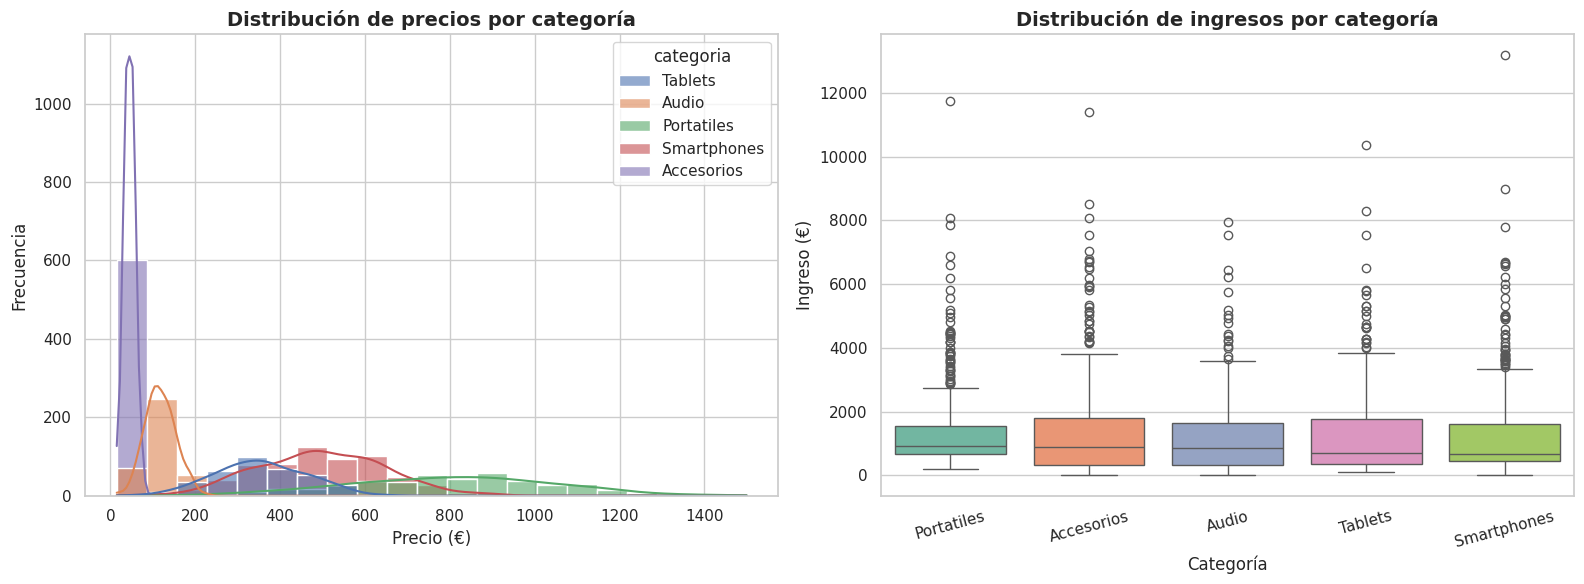

In [30]:
# EJERCICIO 1: Distribución de ventas por producto
# Dataset disponible: df (DataFrame con mes, region, categoria, precio,
#                         unidades, satisfaccion, descuento, canal_venta, ingreso)

# Aplicar tema limpio de Seaborn
sns.set_theme(style='whitegrid')

# Crear figura con 2 subplots en una fila
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Subplot 1: Histograma de precios ---
# TODO: Usar sns.histplot() con data=df, x='precio', hue='categoria',
#       kde=True, alpha=0.6 y ax=axes[0]
sns.histplot(data=df, x='precio', hue='categoria',
             kde=True, alpha=0.6, ax=axes[0])
axes[0].set_title('Distribución de precios por categoría',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Precio (€)')
axes[0].set_ylabel('Frecuencia')


# --- Subplot 2: Boxplot de ingresos ---
# TODO: Calcular el orden de categorías por mediana de ingreso (descendente)
# orden = df.groupby(...)['ingreso'].median().sort_values(...).index


# TODO: Usar sns.boxplot() con data=df, x='categoria', y='ingreso',
#       order=orden, palette='Set2' y ax=axes[1]
orden = df.groupby('categoria')['ingreso'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='categoria', y='ingreso',
            order=orden, palette='Set2', ax=axes[1])

axes[1].set_title('Distribución de ingresos por categoría',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Categoría')
axes[1].set_ylabel('Ingreso (€)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


<details>
<summary><strong>Solucion (click para ver)</strong></summary>

```python
# EJERCICIO 1: Distribución de ventas por producto

# Aplicar tema limpio de Seaborn
sns.set_theme(style='whitegrid')

# Crear figura con 2 subplots en una fila
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Subplot 1: Histograma de precios por categoría ---
sns.histplot(data=df, x='precio', hue='categoria',
             kde=True, alpha=0.6, ax=axes[0])
axes[0].set_title('Distribución de precios por categoría',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Precio (€)')
axes[0].set_ylabel('Frecuencia')

# --- Subplot 2: Boxplot de ingresos ordenado por mediana ---
orden = df.groupby('categoria')['ingreso'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='categoria', y='ingreso',
            order=orden, palette='Set2', ax=axes[1])
axes[1].set_title('Distribución de ingresos por categoría',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Categoría')
axes[1].set_ylabel('Ingreso (€)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()
```

</details>


---


## Ejercicio 2: Tendencias temporales

**Objetivo:** Analizar la evolución mensual de ingresos por categoría con intervalos de confianza usando lineplot de Seaborn.

El director comercial quiere ver cómo evolucionan los ingresos a lo largo de 2024 para cada categoría de producto. Seaborn lineplot calcula automáticamente la media y el intervalo de confianza al 95% cuando hay múltiples observaciones por mes, lo que facilita detectar tendencias y variabilidad sin código adicional.



### Tareas

- Crear una figura individual grande con figsize=(14, 7)
- Usar sns.lineplot() con data=df, x='mes', y='ingreso', hue='categoria'
- Personalizar con errorbar=('ci', 95) y marker='o'
- Mover la leyenda fuera del gráfico para no tapar datos
- Añadir título, etiquetas de ejes y cuadrícula


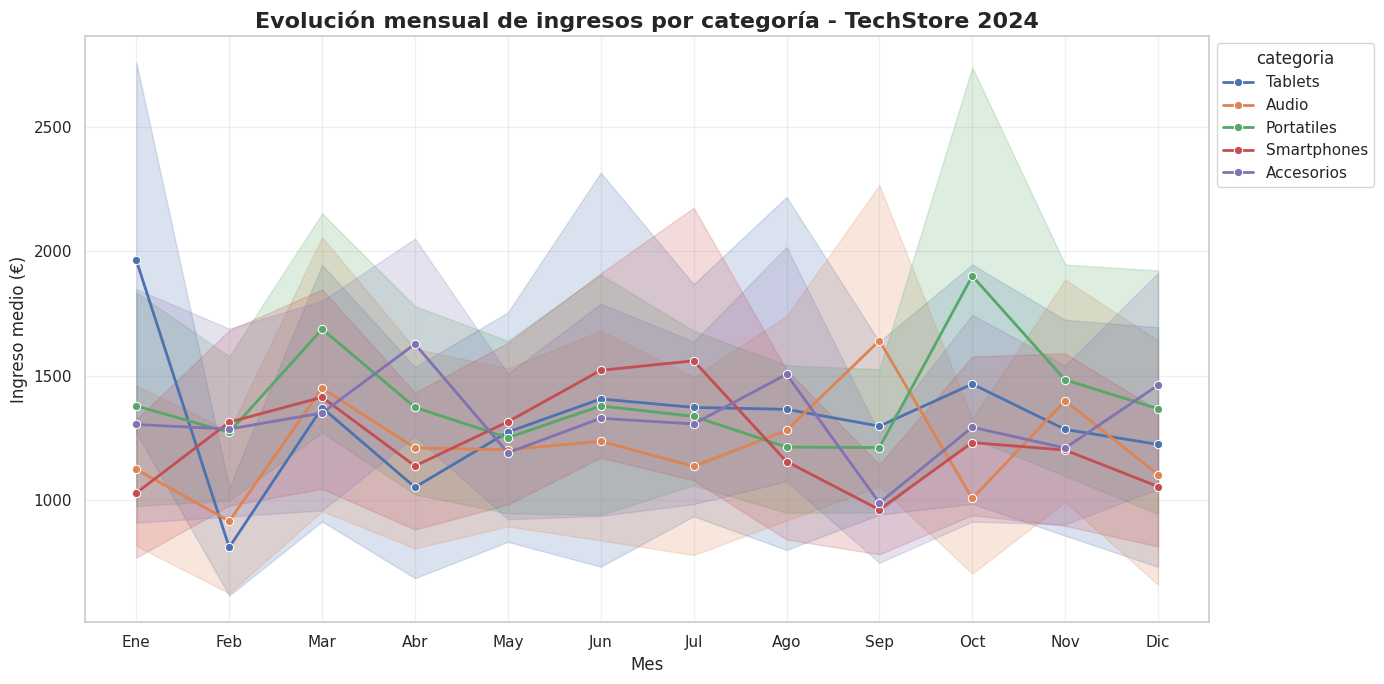

In [33]:
# EJERCICIO 2: Tendencias temporales
# Dataset disponible: df (2.400 registros con mes categórico ordenado)

# TODO: Crear figura grande
fig, ax = plt.subplots(figsize=(14, 7))


# TODO: Crear lineplot con Seaborn
# - data=df, x='mes', y='ingreso', hue='categoria'
# - errorbar=('ci', 95) para intervalo de confianza al 95%
# - marker='o', linewidth=2
sns.lineplot(data=df, x='mes', y='ingreso', hue='categoria',
             errorbar=('ci', 95), marker='o', linewidth=2, ax=ax)

# TODO: Mover la leyenda fuera del gráfico
# Opción 1: sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
# Opción 2: ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

# Personalización
# TODO: Añadir título, etiquetas de ejes y cuadrícula
ax.set_title('Evolución mensual de ingresos por categoría - TechStore 2024',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Mes', fontsize=12)
ax.set_ylabel('Ingreso medio (€)', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


<details>
<summary><strong>Solucion (click para ver)</strong></summary>

```python
# EJERCICIO 2: Tendencias temporales

# Crear figura grande
fig, ax = plt.subplots(figsize=(14, 7))

# Lineplot con intervalos de confianza al 95%
sns.lineplot(data=df, x='mes', y='ingreso', hue='categoria',
             errorbar=('ci', 95), marker='o', linewidth=2, ax=ax)

# Mover leyenda fuera del gráfico
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

# Personalización
ax.set_title('Evolución mensual de ingresos por categoría - TechStore 2024',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Mes', fontsize=12)
ax.set_ylabel('Ingreso medio (€)', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
```

</details>


---


## Ejercicio 3: Comparativa por región

**Objetivo:** Comparar el rendimiento comercial de las 5 tiendas mediante gráficos de barras y conteo.

El director quiere saber qué tienda genera más ingresos medios y cuál tiene mayor volumen de ventas. Además, interesa ver si hay diferencias en la proporción de ventas Online vs Tienda física entre regiones. Seaborn facilita estas comparativas con barplot y countplot.



### Tareas

- Crear una figura con 1 fila y 2 columnas (figsize=(16, 6))
- En el primer subplot: barplot de ingreso medio por región, ordenado de mayor a menor
- En el segundo subplot: countplot de ventas por región con hue=canal_venta
- Añadir títulos y rotar etiquetas del eje X si es necesario


/tmp/ipykernel_943/2724456012.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='region', y='ingreso',


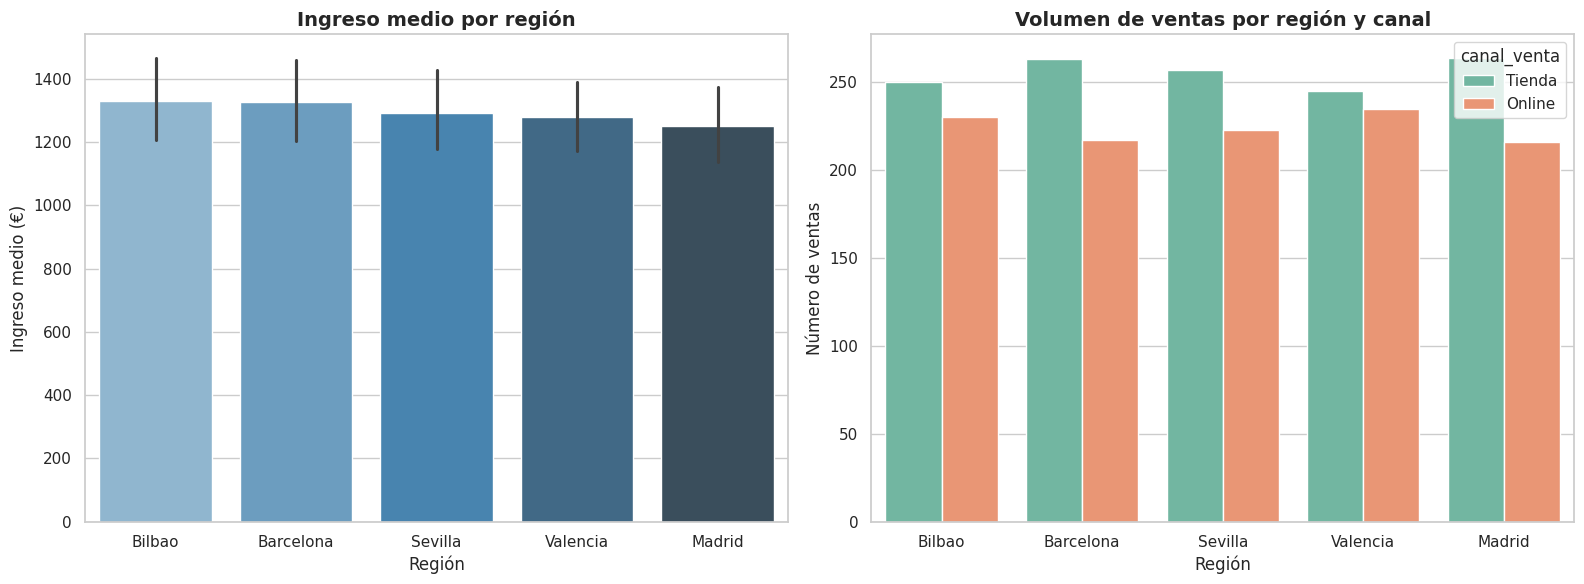

In [38]:
# EJERCICIO 3: Comparativa por región
# Dataset disponible: df (con columnas region, ingreso, canal_venta)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Calcular orden de regiones por ingreso medio descendente
orden_region = df.groupby('region')['ingreso'].mean().sort_values(ascending=False).index

# --- Subplot 1: Barplot de ingreso medio ---
# TODO: Usar sns.barplot() con data=df, x='region', y='ingreso',
#       order=orden_region, palette='Blues_d', errorbar='ci', ax=axes[0]
sns.barplot(data=df, x='region', y='ingreso',
            order=orden_region, palette='Blues_d',
            errorbar='ci', ax=axes[0])

axes[0].set_title('Ingreso medio por región',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Región')
axes[0].set_ylabel('Ingreso medio (€)')

# --- Subplot 2: Countplot por canal de venta ---
# TODO: Usar sns.countplot() con data=df, x='region', hue='canal_venta',
#       order=orden_region, palette='Set2', ax=axes[1]
sns.countplot(data=df, x='region', hue='canal_venta',
              order=orden_region, palette='Set2', ax=axes[1])

axes[1].set_title('Volumen de ventas por región y canal',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Región')
axes[1].set_ylabel('Número de ventas')

plt.tight_layout()
plt.show()


<details>
<summary><strong>Solucion (click para ver)</strong></summary>

```python
# EJERCICIO 3: Comparativa por región

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Orden de regiones por ingreso medio descendente
orden_region = df.groupby('region')['ingreso'].mean().sort_values(ascending=False).index

# --- Subplot 1: Barplot de ingreso medio por región ---
sns.barplot(data=df, x='region', y='ingreso',
            order=orden_region, palette='Blues_d',
            errorbar='ci', ax=axes[0])
axes[0].set_title('Ingreso medio por región',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Región')
axes[0].set_ylabel('Ingreso medio (€)')

# --- Subplot 2: Countplot por canal de venta ---
sns.countplot(data=df, x='region', hue='canal_venta',
              order=orden_region, palette='Set2', ax=axes[1])
axes[1].set_title('Volumen de ventas por región y canal',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Región')
axes[1].set_ylabel('Número de ventas')

plt.tight_layout()
plt.show()
```

</details>


---


## Ejercicio 4: Outliers y dispersión

**Objetivo:** Detectar valores atípicos y visualizar la dispersión real de los datos combinando boxplot y stripplot.

Los boxplots muestran un resumen estadístico pero ocultan la distribución real de los datos. Superponer un stripplot (o swarmplot) sobre el boxplot revela cada punto individual, permitiendo identificar agrupaciones, vacíos y outliers reales. Nota: si swarmplot es muy lento con muchos datos, usa stripplot con alpha bajo o trabaja con una muestra de 200 registros (df.sample(200, random_state=42)).



### Tareas

- Crear una figura individual con figsize=(12, 7)
- Dibujar un boxplot de precio por categoría como base
- Superponer un stripplot con una muestra de 200 registros para rendimiento
- Usar alpha=0.3 y jitter=True en el stripplot para evitar solapamiento
- Añadir título y personalizar el gráfico


/tmp/ipykernel_943/699507966.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='categoria', y='precio',


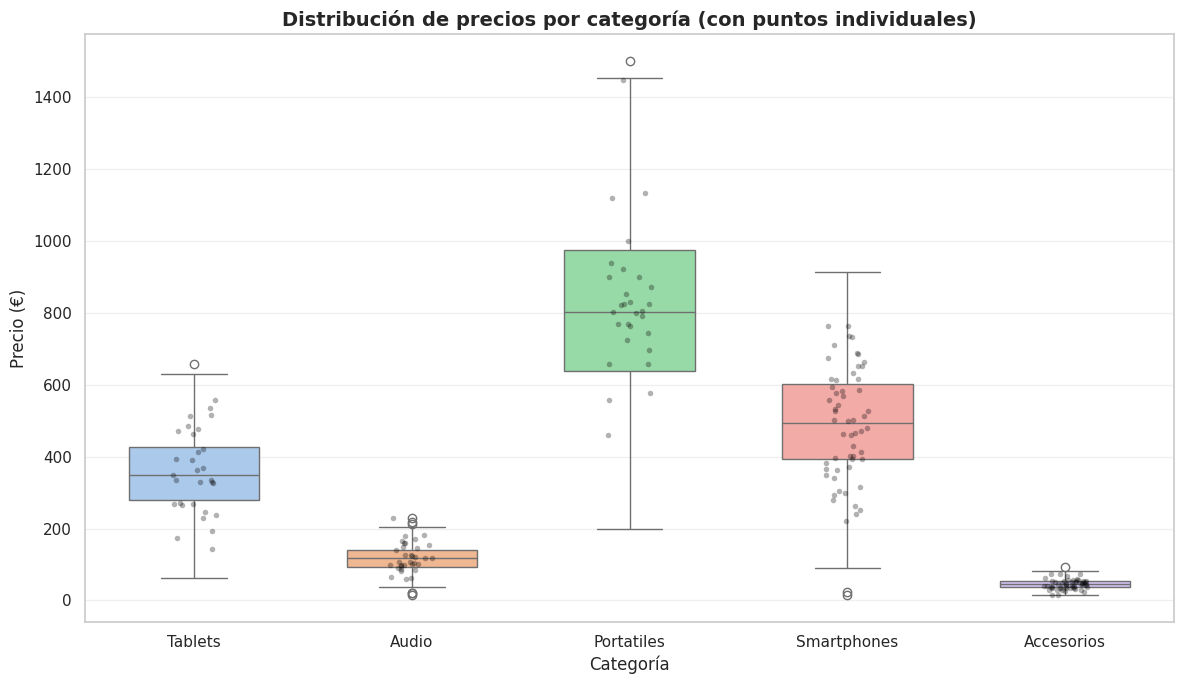

In [39]:
# EJERCICIO 4: Outliers y dispersión
# Dataset disponible: df (2.400 registros)
# Nota: Si swarmplot es lento, usa stripplot o una muestra con df.sample()

fig, ax = plt.subplots(figsize=(12, 7))

# TODO: Dibujar boxplot de precio por categoría
# Usar sns.boxplot() con palette='pastel', width=0.6
sns.boxplot(data=df, x='categoria', y='precio',
            palette='pastel', width=0.6, ax=ax)

# TODO: Crear una muestra de 200 registros para rendimiento
# muestra = df.sample(200, random_state=42)
muestra = df.sample(200, random_state=42)

# TODO: Superponer stripplot con la muestra
# Usar sns.stripplot() con color='black', alpha=0.3, size=4, jitter=True
sns.stripplot(data=muestra, x='categoria', y='precio', color='black', alpha=0.3, size=4, jitter=True, ax=ax)

# Personalización
ax.set_title('Distribución de precios por categoría (con puntos individuales)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Categoría', fontsize=12)
ax.set_ylabel('Precio (€)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


<details>
<summary><strong>Solucion (click para ver)</strong></summary>

```python
# EJERCICIO 4: Outliers y dispersión

fig, ax = plt.subplots(figsize=(12, 7))

# Boxplot base con colores suaves
sns.boxplot(data=df, x='categoria', y='precio',
            palette='pastel', width=0.6, ax=ax)

# Muestra aleatoria para el stripplot (rendimiento)
muestra = df.sample(200, random_state=42)

# Stripplot superpuesto
sns.stripplot(data=muestra, x='categoria', y='precio',
              color='black', alpha=0.3, size=4,
              jitter=True, ax=ax)

# Personalización
ax.set_title('Distribución de precios por categoría (con puntos individuales)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Categoría', fontsize=12)
ax.set_ylabel('Precio (€)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
```

</details>


---


## Ejercicio 5: Correlaciones de KPIs

**Objetivo:** Analizar las correlaciones entre las variables numéricas del negocio con un mapa de calor profesional.

El equipo de análisis necesita identificar qué variables están relacionadas. Por ejemplo, ¿un mayor descuento se asocia con más unidades vendidas? ¿La satisfacción del cliente correlaciona con el precio? Un heatmap de la matriz de correlación con máscara triangular es la herramienta estándar para este análisis.



### Tareas

- Seleccionar las columnas numéricas: precio, unidades, satisfaccion, descuento, ingreso
- Calcular la matriz de correlación con .corr()
- Crear una máscara triangular superior con np.triu(np.ones_like(...))
- Dibujar el heatmap con annot=True, fmt='.2f', cmap='RdBu_r' y la máscara
- Ajustar tamaño de figura para que sea cuadrado y legible


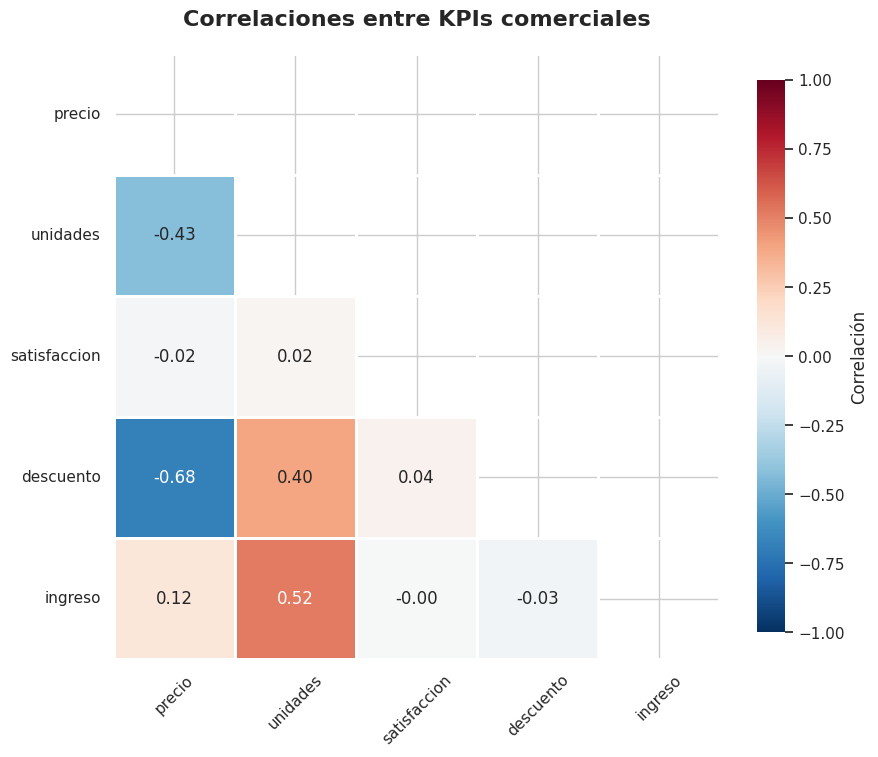

In [41]:
# EJERCICIO 5: Correlaciones de KPIs
# Dataset disponible: df (columnas numéricas: precio, unidades, satisfaccion, descuento, ingreso)

# Seleccionar columnas numéricas
cols_num = ['precio', 'unidades', 'satisfaccion', 'descuento', 'ingreso']

# TODO: Calcular la matriz de correlación
# corr = df[cols_num].corr()
corr = df[cols_num].corr()

# TODO: Crear máscara triangular superior
# mask = np.triu(np.ones_like(corr, dtype=bool))
mask = np.triu(np.ones_like(corr, dtype=bool))

# Crear figura cuadrada
fig, ax = plt.subplots(figsize=(9, 8))

# TODO: Dibujar heatmap con Seaborn
# Usar sns.heatmap() con:
#   - mask=mask, annot=True, fmt='.2f'
#   - cmap='RdBu_r', center=0, vmin=-1, vmax=1
#   - square=True, linewidths=1
#   - cbar_kws={'shrink': 0.8, 'label': 'Correlación'}
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
cmap='RdBu_r', center=0, vmin=-1, vmax=1,
square=True, linewidths=1,
cbar_kws={'shrink': 0.8, 'label': 'Correlación'}, ax=ax)

ax.set_title('Correlaciones entre KPIs comerciales',
             fontsize=16, fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


<details>
<summary><strong>Solucion (click para ver)</strong></summary>

```python
# EJERCICIO 5: Correlaciones de KPIs

# Seleccionar columnas numéricas
cols_num = ['precio', 'unidades', 'satisfaccion', 'descuento', 'ingreso']

# Calcular la matriz de correlación
corr = df[cols_num].corr()

# Crear máscara triangular superior
mask = np.triu(np.ones_like(corr, dtype=bool))

# Crear figura cuadrada
fig, ax = plt.subplots(figsize=(9, 8))

# Heatmap con máscara y anotaciones
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=1,
            cbar_kws={'shrink': 0.8, 'label': 'Correlación'},
            ax=ax)

ax.set_title('Correlaciones entre KPIs comerciales',
             fontsize=16, fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()
```

</details>


---


## Ejercicio 6: Informe visual completo

**Objetivo:** Crear un dashboard profesional 2x2 que resuma los hallazgos clave para el director comercial.

Es hora de consolidar todo el análisis en un único informe visual. El director necesita ver de un vistazo: qué categorías generan más ingresos, cómo difiere la satisfacción por canal, la tendencia mensual por región y un resumen cruzado de ingresos por región y categoría. Este dashboard será la pieza central de la presentación trimestral.



### Tareas

- Crear un grid 2x2 con fig, axes = plt.subplots(2, 2, figsize=(16, 12))
- [0,0]: barplot horizontal de ingreso medio por categoría con palette='viridis'
- [0,1]: kdeplot de satisfacción por canal_venta con fill=True
- [1,0]: lineplot de ingreso medio mensual con hue=region
- [1,1]: heatmap de pivot table (región x categoría) con ingresos medios y annot=True
- Aplicar sns.despine() globalmente y fig.suptitle() como título principal


/tmp/ipykernel_943/1018157417.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, y='categoria', x='ingreso',


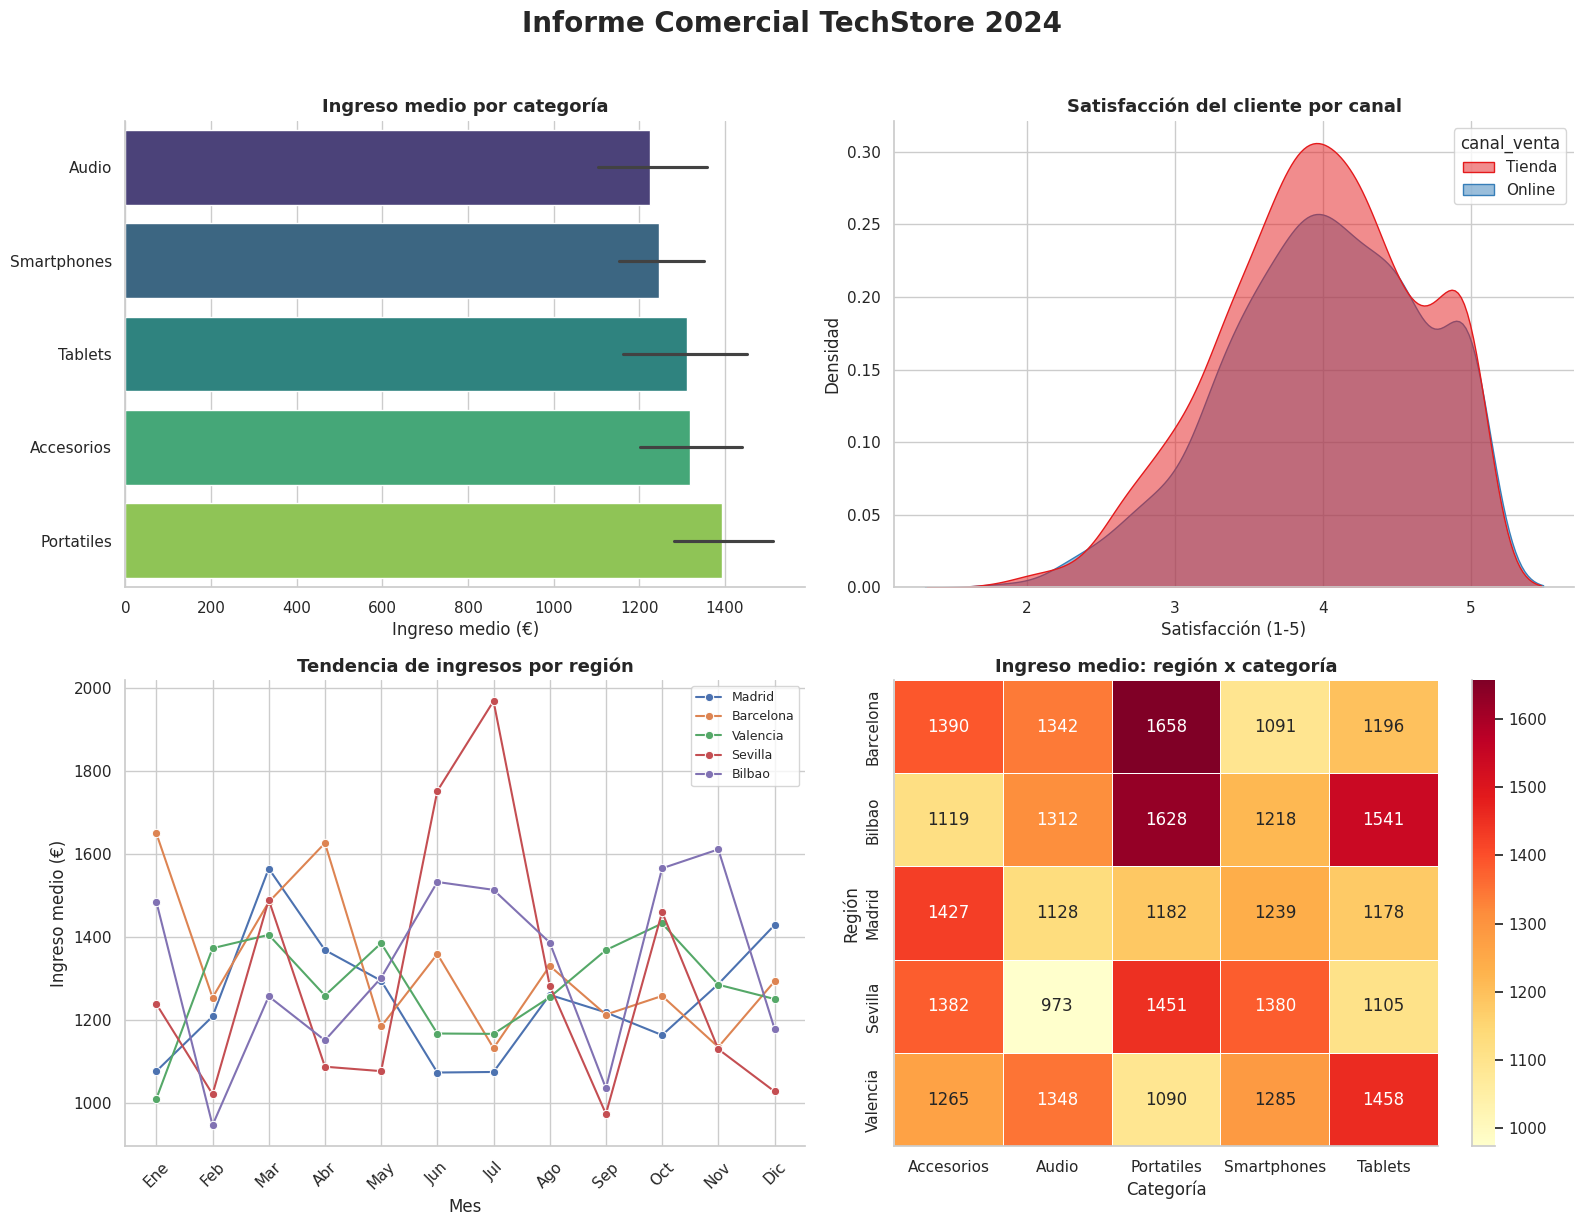

In [42]:
# EJERCICIO 6: Informe visual completo - Dashboard 2x2
# Dataset disponible: df (completo con todas las columnas)

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# === [0,0] Barplot horizontal: Ingreso medio por categoría ===
orden_cat = df.groupby('categoria')['ingreso'].mean().sort_values().index
# TODO: sns.barplot() horizontal (y='categoria', x='ingreso')
#       con order=orden_cat, palette='viridis', errorbar='ci'
orden_cat = df.groupby('categoria')['ingreso'].mean().sort_values().index
sns.barplot(data=df, y='categoria', x='ingreso',
            order=orden_cat, palette='viridis',
            errorbar='ci', ax=axes[0, 0])

axes[0, 0].set_title('Ingreso medio por categoría', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Ingreso medio (€)')
axes[0, 0].set_ylabel('')

# === [0,1] KDE: Satisfacción por canal de venta ===
# TODO: sns.kdeplot() con x='satisfaccion', hue='canal_venta',
#       fill=True, alpha=0.5, palette='Set1'
sns.kdeplot(data=df, x='satisfaccion', hue='canal_venta',
            fill=True, alpha=0.5, palette='Set1', ax=axes[0, 1])

axes[0, 1].set_title('Satisfacción del cliente por canal', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Satisfacción (1-5)')
axes[0, 1].set_ylabel('Densidad')

# === [1,0] Lineplot: Tendencia mensual por región ===
# TODO: sns.lineplot() con x='mes', y='ingreso', hue='region',
#       errorbar=None, marker='o'
sns.lineplot(data=df, x='mes', y='ingreso', hue='region',
             errorbar=None, marker='o', ax=axes[1, 0])

axes[1, 0].set_title('Tendencia de ingresos por región', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Mes')
axes[1, 0].set_ylabel('Ingreso medio (€)')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(fontsize=9)

# === [1,1] Heatmap: Pivot región x categoría ===
# TODO: Crear pivot table con df.pivot_table(values='ingreso',
#       index='region', columns='categoria', aggfunc='mean')
pivot = df.pivot_table(values='ingreso', index='region',
                       columns='categoria', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1, 1])

# TODO: sns.heatmap() con annot=True, fmt='.0f', cmap='YlOrRd',
#       linewidths=0.5


axes[1, 1].set_title('Ingreso medio: región x categoría', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Categoría')
axes[1, 1].set_ylabel('Región')

# Limpieza profesional
sns.despine()
fig.suptitle('Informe Comercial TechStore 2024',
             fontsize=20, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()


<details>
<summary><strong>Solucion (click para ver)</strong></summary>

```python
# EJERCICIO 6: Informe visual completo - Dashboard 2x2

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# === [0,0] Barplot horizontal: Ingreso medio por categoría ===
orden_cat = df.groupby('categoria')['ingreso'].mean().sort_values().index
sns.barplot(data=df, y='categoria', x='ingreso',
            order=orden_cat, palette='viridis',
            errorbar='ci', ax=axes[0, 0])
axes[0, 0].set_title('Ingreso medio por categoría', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Ingreso medio (€)')
axes[0, 0].set_ylabel('')

# === [0,1] KDE: Satisfacción por canal de venta ===
sns.kdeplot(data=df, x='satisfaccion', hue='canal_venta',
            fill=True, alpha=0.5, palette='Set1', ax=axes[0, 1])
axes[0, 1].set_title('Satisfacción del cliente por canal', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Satisfacción (1-5)')
axes[0, 1].set_ylabel('Densidad')

# === [1,0] Lineplot: Tendencia mensual por región ===
sns.lineplot(data=df, x='mes', y='ingreso', hue='region',
             errorbar=None, marker='o', ax=axes[1, 0])
axes[1, 0].set_title('Tendencia de ingresos por región', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Mes')
axes[1, 0].set_ylabel('Ingreso medio (€)')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(fontsize=9)

# === [1,1] Heatmap: Pivot región x categoría ===
pivot = df.pivot_table(values='ingreso', index='region',
                       columns='categoria', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1, 1])
axes[1, 1].set_title('Ingreso medio: región x categoría', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Categoría')
axes[1, 1].set_ylabel('Región')

# Limpieza profesional
sns.despine()
fig.suptitle('Informe Comercial TechStore 2024',
             fontsize=20, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()
```

</details>
